# Protein LM Checkpoint Training

This notebook trains the small ESM-C-style `ProteinLM` used by the folding model. Unlike the explainer notebook, this is the checkpoint-producing path: it reads sequence tokens and residue masks, applies masked-token training, and saves `protein_lm.pt` for the next folding stage.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from plm import ProteinLM, ProteinLMConfig
from plm_dataloader import ProteinBatchLoader
from protein_tokenizer import MASK_ID, MLM_IGNORE_INDEX, ProteinTokenizer

## Devices & Paths

In [2]:
SEED = 1337

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)
print(f'using {device}')

data_root = Path('~/data/protein_folding').expanduser()
shard_path = data_root / 'tokenized'
checkpoint_path = Path('~/model/protein_folding/protein_lm.pt').expanduser()
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)


using cpu


## Setup

We keep the model configuration visible so the checkpoint records the same PLM contract that the folding model will reconstruct later.


In [3]:
batch_size = 4
epochs = 250
lr = 1e-4

In [4]:
train_loader = ProteinBatchLoader(shard_path, 'train', batch_size, device, seed=SEED)
val_loader = ProteinBatchLoader(shard_path, 'val', batch_size, device, seed=SEED + 1)
tokenizer = ProteinTokenizer()
mask_generator = torch.Generator(device=device).manual_seed(SEED + 2)

In [5]:
steps_per_epoch = (train_loader.num_examples + batch_size - 1) // batch_size
val_steps = (val_loader.num_examples + batch_size - 1) // batch_size
max_steps = epochs * steps_per_epoch
print(f'train examples: {train_loader.num_examples:,}')
print(f'val examples: {val_loader.num_examples:,}')
print(f'steps per epoch: {steps_per_epoch:,}')
print(f'total steps: {max_steps:,}')

train examples: 113
val examples: 14
steps per epoch: 29
total steps: 7,250


In [6]:
plm_cfg = ProteinLMConfig(
    vocab_size=64,
    context_size=64,
    embed_dim=64,
    lm_heads=4,
    lm_layers=3,
    mlm_mask_probability=0.15,
    dropout=0.10,
)
plm_cfg


ProteinLMConfig(vocab_size=64, context_size=64, embed_dim=64, lm_heads=4, lm_layers=3, mlm_mask_probability=0.15, dropout=0.1)

In [7]:
model = ProteinLM(plm_cfg).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f'parameters: {parameter_count:,}')

parameters: 210,240


## Train

Each step masks residue tokens using `plm_cfg.mlm_mask_probability`, predicts the original residue IDs at those masked positions, and leaves non-masked positions ignored in the loss. The batch also carries `asym_id`, `residue_index`, and `mol_type` into the PLM so the same metadata-aware wrapping path is trained for the folding model.

In [8]:
loss_history = []
val_history = []
train_loss_total = 0.0
train_correct = 0
train_masked = 0
model.train()

ProteinLM(
  (token_embedding): Embedding(64, 64, padding_idx=1)
  (blocks): ModuleList(
    (0-2): 3 x ProteinTransformerBlock(
      (attention_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attention): ProteinSelfAttention(
        (qkv): Linear(in_features=64, out_features=192, bias=False)
        (output): Linear(in_features=64, out_features=64, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
        (query_norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (key_norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (rope): RotaryPositionEmbedding()
      )
      (mlp_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (mlp): ProteinMLP(
        (fc): Linear(in_features=64, out_features=512, bias=False)
        (projection): Linear(in_features=256, out_features=64, bias=False)
      )
    )
  )
  (final_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (sequence_head): Sequential(
    (0): Lin

In [9]:
for step in range(1, max_steps + 1):
    batch = train_loader.next_batch()
    masked_input_ids, mlm_targets = tokenizer.mask_tokens(
        batch['input_ids'],
        batch['residue_mask'],
        mask_probability=plm_cfg.mlm_mask_probability,
        generator=mask_generator,
    )
    if not (mlm_targets != MLM_IGNORE_INDEX).any():
        valid_positions = torch.nonzero(batch['residue_mask'], as_tuple=False)
        batch_index, residue_index = valid_positions[0].tolist()
        mlm_targets[batch_index, residue_index] = batch['input_ids'][batch_index, residue_index]
        masked_input_ids[batch_index, residue_index] = MASK_ID

    output = model(
        masked_input_ids,
        batch['residue_mask'],
        mlm_targets=mlm_targets,
        asym_id=batch['asym_id'],
        residue_index=batch['residue_index'],
        mol_type=batch['mol_type'],
    )
    loss = output['loss']

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    supervised = mlm_targets != MLM_IGNORE_INDEX
    train_correct += int(((output['mlm_logits'].argmax(dim=-1) == mlm_targets) & supervised).sum().item())
    train_masked += int(supervised.sum().item())
    train_loss_total += float(loss.item())
    loss_history.append(float(loss.item()))

    if step % steps_per_epoch == 0:
        model.eval()
        val_loader.reset()
        val_loss_total = 0.0
        val_correct = 0
        val_masked = 0
        with torch.no_grad():
            for _ in range(val_steps):
                batch = val_loader.next_batch()
                masked_input_ids, mlm_targets = tokenizer.mask_tokens(
                    batch['input_ids'],
                    batch['residue_mask'],
                    mask_probability=plm_cfg.mlm_mask_probability,
                    generator=mask_generator,
                )
                if not (mlm_targets != MLM_IGNORE_INDEX).any():
                    valid_positions = torch.nonzero(batch['residue_mask'], as_tuple=False)
                    batch_index, residue_index = valid_positions[0].tolist()
                    mlm_targets[batch_index, residue_index] = batch['input_ids'][batch_index, residue_index]
                    masked_input_ids[batch_index, residue_index] = MASK_ID
                output = model(
                    masked_input_ids,
                    batch['residue_mask'],
                    mlm_targets=mlm_targets,
                    asym_id=batch['asym_id'],
                    residue_index=batch['residue_index'],
                    mol_type=batch['mol_type'],
                )
                supervised = mlm_targets != MLM_IGNORE_INDEX
                val_correct += int(((output['mlm_logits'].argmax(dim=-1) == mlm_targets) & supervised).sum().item())
                val_masked += int(supervised.sum().item())
                val_loss_total += float(output['loss'].item())

        epoch = step // steps_per_epoch
        train_loss = train_loss_total / steps_per_epoch
        train_accuracy = train_correct / max(train_masked, 1)
        val_loss = val_loss_total / val_steps
        val_accuracy = val_correct / max(val_masked, 1)
        val_history.append((step, val_loss, val_accuracy))
        print(f'epoch {epoch:2d} | train loss {train_loss:.4f} | train acc {train_accuracy:.3f} | val loss {val_loss:.4f} | val acc {val_accuracy:.3f}')

        train_loss_total = 0.0
        train_correct = 0
        train_masked = 0
        model.train()

torch.save(
    {
        'stage': 'protein_lm_pretraining',
        'model': model.state_dict(),
        'config': plm_cfg.__dict__,
        'step': max_steps,
        'loss_history': loss_history,
        'val_history': val_history,
    },
    checkpoint_path,
)
print(f'saved checkpoint: {checkpoint_path}')


epoch  1 | train loss 4.0035 | train acc 0.055 | val loss 3.8846 | val acc 0.043
epoch  2 | train loss 3.7877 | train acc 0.055 | val loss 3.7055 | val acc 0.041
epoch  3 | train loss 3.6243 | train acc 0.057 | val loss 3.5450 | val acc 0.071
epoch  4 | train loss 3.4688 | train acc 0.070 | val loss 3.3930 | val acc 0.085
epoch  5 | train loss 3.3809 | train acc 0.068 | val loss 3.3073 | val acc 0.081
epoch  6 | train loss 3.2766 | train acc 0.069 | val loss 3.2299 | val acc 0.066
epoch  7 | train loss 3.1980 | train acc 0.093 | val loss 3.1638 | val acc 0.091
epoch  8 | train loss 3.1446 | train acc 0.075 | val loss 3.0969 | val acc 0.050
epoch  9 | train loss 3.1094 | train acc 0.071 | val loss 3.1061 | val acc 0.062
epoch 10 | train loss 3.0950 | train acc 0.088 | val loss 3.0592 | val acc 0.129
epoch 11 | train loss 3.0522 | train acc 0.081 | val loss 3.0632 | val acc 0.085
epoch 12 | train loss 3.0489 | train acc 0.082 | val loss 3.0166 | val acc 0.101
epoch 13 | train loss 3.0016

## Loss Curve

After training, we plot the masked language-model loss and inspect the output tensors that the folding path expects: gathered hidden states and MLM logits. The final normalized residue state is the last hidden-state layer, so we do not return a separate duplicate `embeddings` tensor.


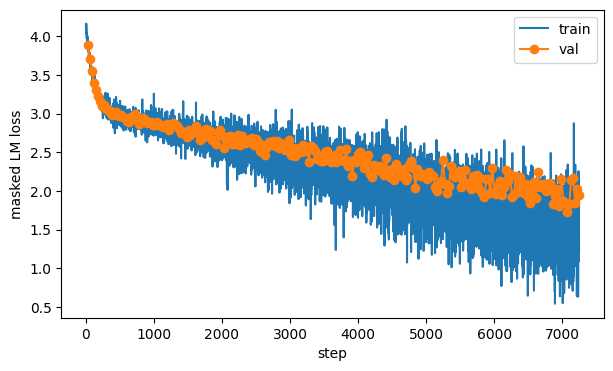

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history, label='train')
if val_history:
    steps = [item[0] for item in val_history]
    values = [item[1] for item in val_history]
    plt.plot(steps, values, marker='o', label='val')
plt.xlabel('step')
plt.ylabel('masked LM loss')
plt.legend()
plt.show()

In [11]:
batch = val_loader.next_batch()
model.eval()
with torch.no_grad():
    output = model(
        batch['input_ids'],
        batch['residue_mask'],
        asym_id=batch['asym_id'],
        residue_index=batch['residue_index'],
        mol_type=batch['mol_type'],
    )

output['hidden_states'].shape, output['mlm_logits'].shape


(torch.Size([4, 64, 4, 64]), torch.Size([4, 64, 64]))

In [12]:
output['hidden_states'][:, :, -1].shape, output['hidden_states'][:, :, -1]

(torch.Size([4, 64, 64]),
 tensor([[[-0.6311,  0.3820,  0.7263,  ...,  0.3850,  0.4298, -1.4668],
          [ 0.1348,  0.5893,  1.7629,  ..., -1.2018, -1.9778, -0.6201],
          [ 0.6662,  0.1982,  0.8011,  ...,  0.5709, -1.1018, -0.8331],
          ...,
          [-0.0000,  0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000],
          [-0.0000,  0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000],
          [-0.0000,  0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000]],
 
         [[-1.3474, -1.4412, -1.6573,  ...,  0.2769, -0.6177,  1.5954],
          [-0.1405, -2.2132,  0.0611,  ...,  0.5112,  1.4277, -0.7568],
          [ 0.5989, -0.0745,  1.3204,  ..., -0.5480,  1.3932,  1.3063],
          ...,
          [-0.0000, -0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000],
          [-0.0000, -0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000],
          [-0.0000, -0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000]],
 
         [[-0.5199,  0.1898,  1.2290,  ..., -1.2361, -0.8754,  0.0539],
  

In [13]:
output['hidden_states'].shape, output['hidden_states']

(torch.Size([4, 64, 4, 64]),
 tensor([[[[-7.8696e-03,  2.1300e-03, -3.8868e-04,  ...,  2.4993e-03,
             1.9512e-02, -1.2649e-02],
           [-5.8895e-03, -1.6527e-02, -6.4993e-03,  ..., -1.2432e-03,
             2.3911e-02, -1.8060e-02],
           [ 1.4640e-02,  1.5800e-02,  1.5567e-02,  ...,  1.4336e-02,
             3.1933e-02, -3.3100e-02],
           [-6.3108e-01,  3.8201e-01,  7.2629e-01,  ...,  3.8496e-01,
             4.2980e-01, -1.4668e+00]],
 
          [[ 1.2614e-02,  2.6692e-02,  2.0349e-02,  ..., -2.2529e-02,
            -1.9432e-03, -1.9109e-02],
           [-4.5035e-03,  3.5171e-02,  1.9266e-02,  ..., -4.8030e-02,
            -1.8078e-02, -4.0687e-02],
           [ 3.1529e-02,  5.1871e-03,  8.6293e-02,  ..., -7.0663e-02,
            -8.9625e-02, -1.9182e-02],
           [ 1.3476e-01,  5.8928e-01,  1.7629e+00,  ..., -1.2018e+00,
            -1.9778e+00, -6.2014e-01]],
 
          [[ 2.3389e-02, -3.6063e-02,  1.5296e-02,  ..., -5.1400e-03,
            -1.7376e-02

In [14]:
output['mlm_logits'].shape, output['mlm_logits']

(torch.Size([4, 64, 64]),
 tensor([[[-3.0799, -2.6674, -2.7722,  ..., -2.7468, -2.8323, -2.7004],
          [-4.1943, -3.5703, -3.7050,  ..., -3.8394, -3.9521, -3.7433],
          [-0.9144, -0.6420, -0.9807,  ..., -0.6893, -0.4406, -0.7520],
          ...,
          [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
          [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
          [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000]],
 
         [[-2.8094, -2.6504, -3.1401,  ..., -2.8666, -2.6176, -2.6573],
          [-1.1724, -1.3854, -1.0831,  ..., -1.5345, -1.0845, -1.0774],
          [-1.2327, -0.8111, -0.8013,  ..., -1.1518, -1.3627, -1.2097],
          ...,
          [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
          [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
          [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000]],
 
         [[-4.3870, -4.0146, -4.1818,  ..., -4.4135, -4.2540, -4.1434],
  